## Uncertainty in Explanations via XAI Method Perturbation (Vision)

In [1]:
import numpy as np
import tensorflow as tf
import seaborn as sns
from tensorflow.keras import layers, models
from skimage.color import gray2rgb
import matplotlib.pyplot as plt
import cv2
import pickle
from xplique.attributions import (IntegratedGradients, Lime,  Occlusion, SmoothGrad)

### Load dataset

In [2]:
# Load and Prepare MNIST Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  # Normalize to [0, 1]
x_train = gray2rgb(x_train) # for RGB
x_test = gray2rgb(x_test)
#x_train = x_train[..., np.newaxis] # for grayscale
#x_test = x_test[..., np.newaxis]

In [3]:
# Whether to train a model or load a pretrained one
train_model = False
model_path = './models/cnn_mnist.h5' # with relu
#model_path = './models/cnn_mnist_no_relu.h5'

In [4]:
if train_model:
    # Build and train a simple CNN
    
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation=None, input_shape=(28, 28, 3)), # RGB
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation=None),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation=None),
        layers.Dense(10, activation='softmax')
    ])
    """
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 3)), # RGB
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    """

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(x_train, y_train, epochs=2, batch_size=64, validation_split=0.25)
    model.save(model_path)
else:
    model = tf.keras.models.load_model(model_path)
# XAI methods require removal of Softmax
model.layers[-1].activation = tf.keras.activations.linear

### 'Mean empirical MUE per sigma_squared' for different default XAI parameters

In [57]:
xai_methods  = {'Lime': lambda model, default_param: Lime(model, kernel_width = default_param, batch_size=1, nb_samples=100), # stochastic
                #'SmoothGrad': lambda model, default_param: SmoothGrad(model, noise = default_param, batch_size=1),  # stochastic
                'IntegratedGradients': lambda model, default_param: IntegratedGradients(model, steps = default_param, batch_size=1), # deterministic
                'Occlusion': lambda model, default_param: Occlusion(model, occlusion_value = default_param, batch_size=1), # deterministic
                }

In [ ]:
stds_float = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1] # for floats
stds_int = [2, 3, 4, 5] # for ints

num_perturbations = 10 # for empirical cov.
h, w, c = x_train[0].shape # (28, 28, 3)
n = 1 # just one XAI param. analyzed
m = h * w # explanation features

default_params = {
    'default_kws': [1, 2, 3, 4, 5], # lime
    #'default_smooth_noises': [0.1, 0.2, 0.3, 0.4, 0.5], # smooth grad.
    'default_steps': [20, 30, 40, 50, 60, 70, 80], # integ. grads
    'default_ovs': [0.0, 0.25, 0.5, 0.75, 1.0] # occlusion
}

In [59]:
sample_indexes = [0, 1, 2, 4, 5, 6, 7, 8, 9, 11]
results = {}

for default_params_name, xai_method_name in zip(default_params, xai_methods):
    
    print('\n*** ' + xai_method_name + ' ***')
    default_params_list = default_params[default_params_name]
    stds = stds_int if xai_method_name == 'IntegratedGradients' else stds_float
    results[xai_method_name] = {}
    
    for default_param in default_params_list:
        
        print(default_params_name + ' = ' + str(default_param))
        explainer = xai_methods[xai_method_name](model, default_param)
        
        mue_per_s2 = 0.0
        for sample_index in sample_indexes:
            # Read sample image and label
            sample_image, sample_label = x_test[sample_index], y_test[sample_index]
            sample_label = np.expand_dims(sample_label, axis=[0,1])
            
            explanation = explainer(np.expand_dims(sample_image, axis=0), sample_label)[0] # sample explanation
            # Norm of explanation (for normalization of total variance)
            norm_exp_squared = np.linalg.norm(explanation)**2
            
            for std in stds:
            
                perturbed_explanations = []
                for _ in range(num_perturbations):
                    # Add Gaussian noise to the XAI parameter                
                    if xai_method_name == 'IntegratedGradients':
                        perturbed_param = max( int(np.round(default_param + np.random.normal(0, std, n))), 1 )
                    else:
                        perturbed_param = (default_param + np.random.normal(0, std, n))[0].astype(np.float32)

                    # Generate explanation for perturbed parameter
                    perturbed_explainer = xai_methods[xai_method_name](model, perturbed_param)
                    perturbed_explanation = perturbed_explainer(np.expand_dims(sample_image, axis=0), sample_label)[0]
                    perturbed_explanations.append(perturbed_explanation.numpy().flatten())
            
                # Stack explanations and compute covariance matrix
                explanation_matrix = np.stack(perturbed_explanations, axis=0).squeeze()
                empirical_covariance = np.cov(explanation_matrix, rowvar=False)

                # Compute total variance (trace of the covariance matrix)
                mue_per_s2 += np.trace(empirical_covariance) / norm_exp_squared / m / (std**2) # per sigma squared
                
        mue_per_s2 /= (len(stds) * len(sample_indexes)) # aggregated over samples and stds
        results[xai_method_name][default_param] = mue_per_s2


*** Lime ***
default_kws = 1
default_kws = 2
default_kws = 3
default_kws = 4
default_kws = 5

*** IntegratedGradients ***
default_steps = 20
default_steps = 30
default_steps = 40
default_steps = 50
default_steps = 60
default_steps = 70
default_steps = 80

*** Occlusion ***
default_ovs = 0.0
default_ovs = 0.25
default_ovs = 0.5
default_ovs = 0.75
default_ovs = 1.0


In [60]:
# Store dictionary
with open('./experiments/defaults_explainer_mnist.pickle', 'wb') as handle:
    pickle.dump(results, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
# Load dictionary
with open('./experiments/defaults_explainer_mnist.pickle', 'rb') as handle:
    results = pickle.load(handle)

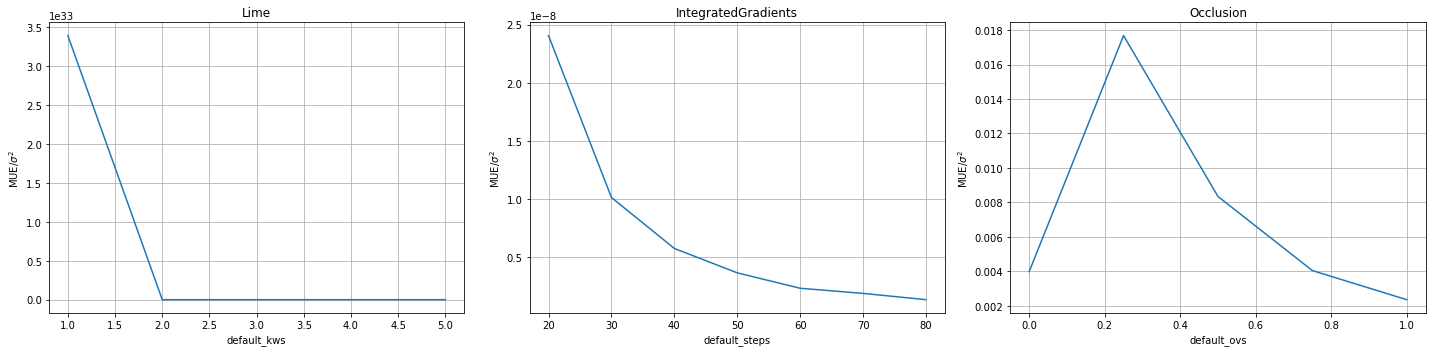

In [61]:
plt.figure(figsize=(20,5))
for (i, xai_method_name), default_param_name in zip(enumerate(xai_methods), default_params):
    plt.subplot(1, len(xai_methods), i+1)
    plt.plot(default_params[default_param_name], results[xai_method_name].values())
    plt.title(xai_method_name)
    plt.xlabel(default_param_name)
    plt.ylabel('MUE/$\sigma^2$')
    plt.grid()
plt.tight_layout()
plt.show()

### Analytical vs Empirical (multiple methods, multiple variances)

In [5]:
xai_methods  = {'Lime': lambda model, default_param: Lime(model, kernel_width = default_param, batch_size=1, nb_samples=100), # stochastic
                'SmoothGrad': lambda model, default_param: SmoothGrad(model, noise = default_param, batch_size=1),  # stochastic
                'IntegratedGradients': lambda model, default_param: IntegratedGradients(model, steps = default_param, batch_size=1), # deterministic
                'Occlusion': lambda model, default_param: Occlusion(model, occlusion_value = default_param, batch_size=1), # deterministic
                }

In [6]:
stds_float = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1] # for floats
stds_int = [2, 3, 4, 5] # for ints
dtheta_float, dtheta_int = 1e-3, 1

num_perturbations = 10 # for empirical cov.
h, w, c = x_train[0].shape # (28, 28, 3)
n = 1 # just one XAI param. analyzed
m = h * w # explanation features

default_params = {
    'default_kw': 1.0, # lime
    'default_smooth_noise': 0.2, # smooth grad.
    'default_steps': 50, # integ. grads
    'default_ovs': 0.2 # occlusion
}

In [8]:
sample_indexes = [0, 1, 2, 4, 5, 6, 7, 8, 9, 11] # samples 3 and 10 yields NaNs
results, jacobi_mats, empirical_exps, unperturbed_exps = {}, {}, {}, {}

# Load weights only once
weights, bias = model.layers[-1].get_weights()

for sample_index in sample_indexes:
    # Read sample image and label
    sample_image, sample_label = x_test[sample_index], y_test[sample_index]
    sample_label = np.expand_dims(sample_label, axis=[0,1])

    # Store results for plotting
    results[sample_index]  = {name: {'analytical': [], 'empirical': []} for name in xai_methods.keys()}
    jacobi_mats[sample_index] = {}
    empirical_exps[sample_index] = {}
    unperturbed_exps[sample_index] = {}

    print('\n*********')
    print('Sample ' + str(sample_index))
    for (xai_method_name, constructor), default_param in zip(xai_methods.items(), default_params.values()):
        print('\n' + xai_method_name)
        empirical_exps[sample_index][xai_method_name] = {}
        
        # Set the differential step and sigmas according to the type of parameter
        dtheta = dtheta_int if xai_method_name == 'IntegratedGradients' else dtheta_float
        stds = stds_int if xai_method_name == 'IntegratedGradients' else stds_float
        
        # Get explanation for unperturbed explainer
        explainer = constructor(model, default_param = default_param) # instantiate explainer with default params
        explanation = explainer(np.expand_dims(sample_image, axis=0), sample_label)[0]
        unperturbed_exps[sample_index][xai_method_name] = explanation.numpy().flatten()
        
        # Norm of explanation (for normalization of total variance)
        norm_exp_squared = np.linalg.norm(explanation)**2
        
        # Precompute Jacobian (stays fixed for every std)
        derivative_e_theta = np.zeros((m, n))
        # For every XAI param. perturbation, we get a new column in the Jacobian
        for i in range(n):
            # Compute explanations for perturbed explainer
            perturbed_explainer = constructor(model, default_param = default_param + dtheta)
            perturbed_explanation = perturbed_explainer(np.expand_dims(sample_image, axis=0), sample_label)[0]

            # Fill out the corresponding column in the jacobian
            derivative_2d = (perturbed_explanation - explanation) / dtheta
            derivative_e_theta[:, i] = derivative_2d.numpy().reshape(m, )
                    
        jacobi_mats[sample_index][xai_method_name] = derivative_e_theta
        
        jjt = derivative_e_theta @ derivative_e_theta.T # Compute jacobian product only once
        for std in stds:
            ### Analytical
            sigma_squared = std ** 2
            covariance_ana = sigma_squared * jjt
            
            # Total variance is the trace of the cov. matrix
            total_var = np.trace(covariance_ana)/norm_exp_squared
            print("Analytical Variance (std = ", std, "):", total_var)
            results[sample_index][xai_method_name]['analytical'].append(total_var)
            
            ### Empirical
            perturbed_explanations = []
            for _ in range(num_perturbations):
                # Add Gaussian noise to the XAI parameter                
                if xai_method_name == 'IntegratedGradients':
                    perturbed_param = max( int(np.round(default_param + np.random.normal(0, std, n))), 1 )
                else:
                    perturbed_param = (default_param + np.random.normal(0, std, n))[0].astype(np.float32)
    
                # Generate explanation for perturbed parameter
                perturbed_explainer = xai_methods[xai_method_name](model, perturbed_param)
                perturbed_explanation = perturbed_explainer(np.expand_dims(sample_image, axis=0), sample_label)[0]
                perturbed_explanations.append(perturbed_explanation.numpy().flatten())
            
            # Stack explanations and compute covariance matrix
            explanation_matrix = np.stack(perturbed_explanations, axis=0)
            covariance_emp = np.cov(explanation_matrix.squeeze(), rowvar=False)
            
            total_var = np.trace(covariance_emp)/norm_exp_squared
            print("Empirical Variance (std = ", std, "):", total_var)
            results[sample_index][xai_method_name]['empirical'].append(total_var)
            
            # Store explanations for cov_emp and normality checks
            empirical_exps[sample_index][xai_method_name][std] = np.stack(perturbed_explanations, axis=0)


*********
Sample 0

Lime
Analytical Variance (std =  1e-06 ): 32895.58414259952
Empirical Variance (std =  1e-06 ): 5305144004.670033
Analytical Variance (std =  1e-05 ): 3289558.414259954
Empirical Variance (std =  1e-05 ): 7010089830.983968
Analytical Variance (std =  0.0001 ): 328955841.42599523
Empirical Variance (std =  0.0001 ): 2823348855.1216
Analytical Variance (std =  0.001 ): 32895584142.599525
Empirical Variance (std =  0.001 ): 3342283424.4146476
Analytical Variance (std =  0.01 ): 3289558414259.953
Empirical Variance (std =  0.01 ): 7864392542.817421
Analytical Variance (std =  0.1 ): 328955841425995.4
Empirical Variance (std =  0.1 ): 4206793070.779179

SmoothGrad
Analytical Variance (std =  1e-06 ): 2.6028215995993702e-08
Empirical Variance (std =  1e-06 ): 0.011903779373826362
Analytical Variance (std =  1e-05 ): 2.6028215995993702e-06
Empirical Variance (std =  1e-05 ): 0.013500098305685219
Analytical Variance (std =  0.0001 ): 0.000260282159959937
Empirical Variance

In [9]:
# Store experiments
experiments = {'results': results,  
               'jacobi_mats': jacobi_mats, 
               'empirical_exps': empirical_exps, 
               'unperturbed_exps': unperturbed_exps}

with open('./experiments/experiments_explainer_mnist_10ex.pickle', 'wb') as handle:
    pickle.dump(experiments, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# Load experiments
exp_path = './experiments/experiments_explainer_mnist_10ex.pickle' # MUE results
with open(exp_path, 'rb') as handle:
    experiments = pickle.load(handle)

In [10]:
# Aggregate results
agg_results = {name: {'analytical': [], 'empirical': []} for name in xai_methods.keys()}
stds_float, stds_int = np.asarray(stds_float), np.asarray(stds_int)
for xai_method_name in xai_methods.keys():
    stds = stds_int if xai_method_name == 'IntegratedGradients' else stds_float
    agg_sum = np.zeros(len(stds))
    for sample_index in sample_indexes:
        agg_sum += experiments['results'][sample_index][xai_method_name]['analytical']
    agg_results[xai_method_name]['analytical'] = agg_sum/len(sample_indexes)

    agg_sum = np.zeros(len(stds))
    for sample_index in sample_indexes:
        agg_sum += experiments['results'][sample_index][xai_method_name]['empirical']
    agg_results[xai_method_name]['empirical'] = agg_sum/len(sample_indexes)
#agg_results

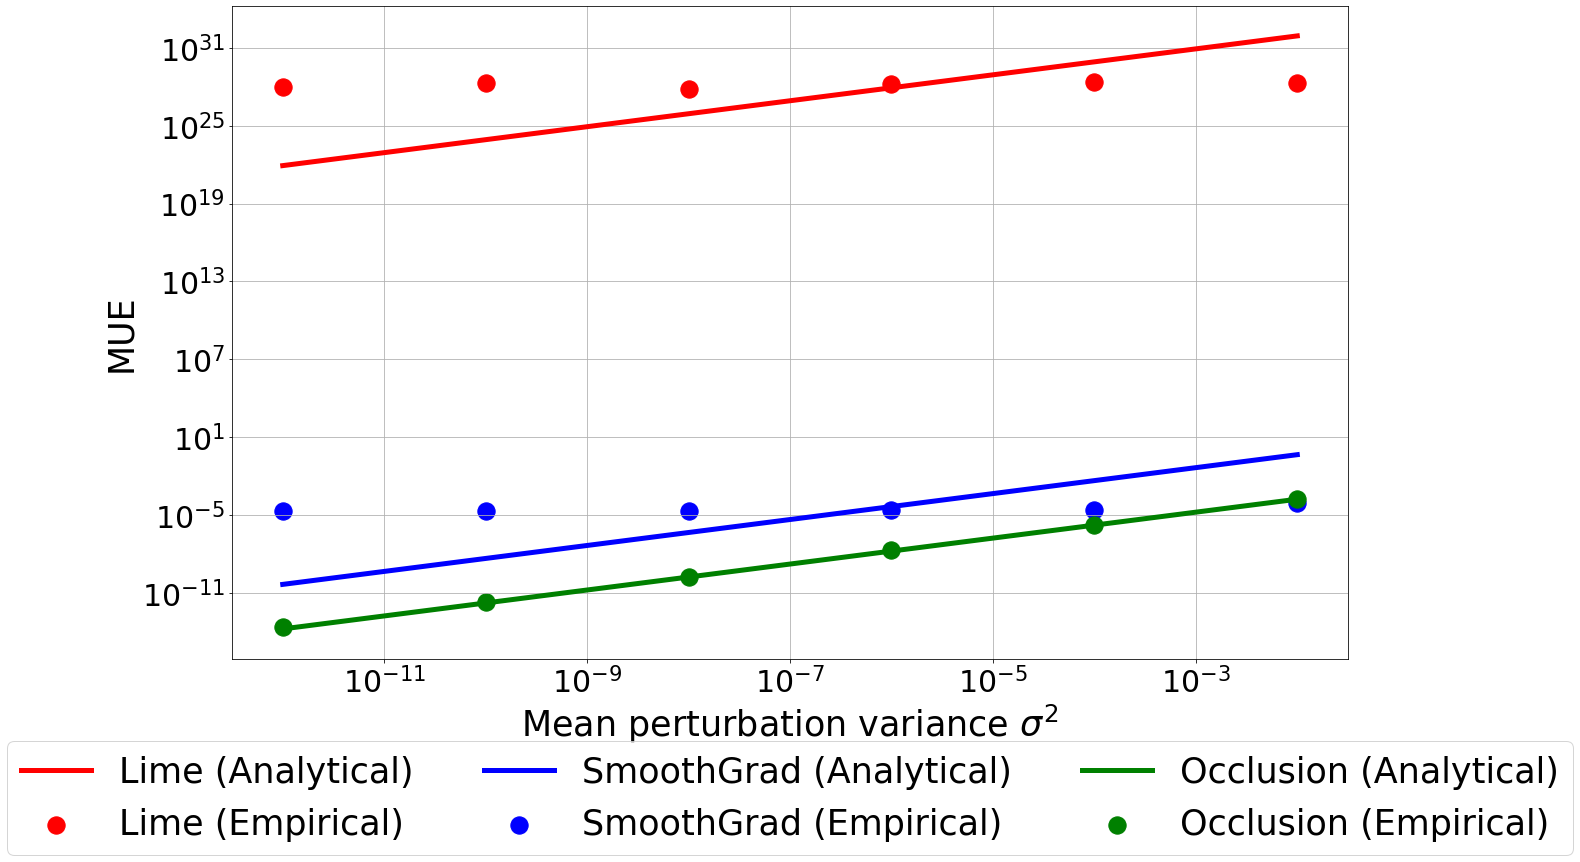

In [11]:
# Plot aggregations for float parameters
colors=['red', 'blue', 'orange', 'green']
stds = np.asarray(stds)
fsize = 35
stds = stds_float
fig = plt.figure(figsize=(20, 12))
for (name, data), col in zip(agg_results.items(), colors):
    if name != 'IntegratedGradients':
        plt.plot(stds*stds, np.asarray(data['analytical'])[:len(stds)]/m, label=f"{name} (Analytical)", c=col, lw=5)
        plt.scatter(stds*stds, np.asarray(data['empirical'])[:len(stds)]/m,  marker='o', 
                    label=f"{name} (Empirical)", c=col, s=300)
plt.xlabel('Mean perturbation variance $\sigma^2$', fontsize=fsize)
plt.ylabel('MUE', fontsize=fsize)
plt.xscale('log'); plt.yscale('log')
plt.xticks(fontsize=fsize-5);plt.yticks(fontsize=fsize-5)
plt.legend(fontsize=fsize, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.grid(True)
plt.show()
#fig.savefig('./figures/uncertainties_input_tabular_agg.png', bbox_inches='tight')

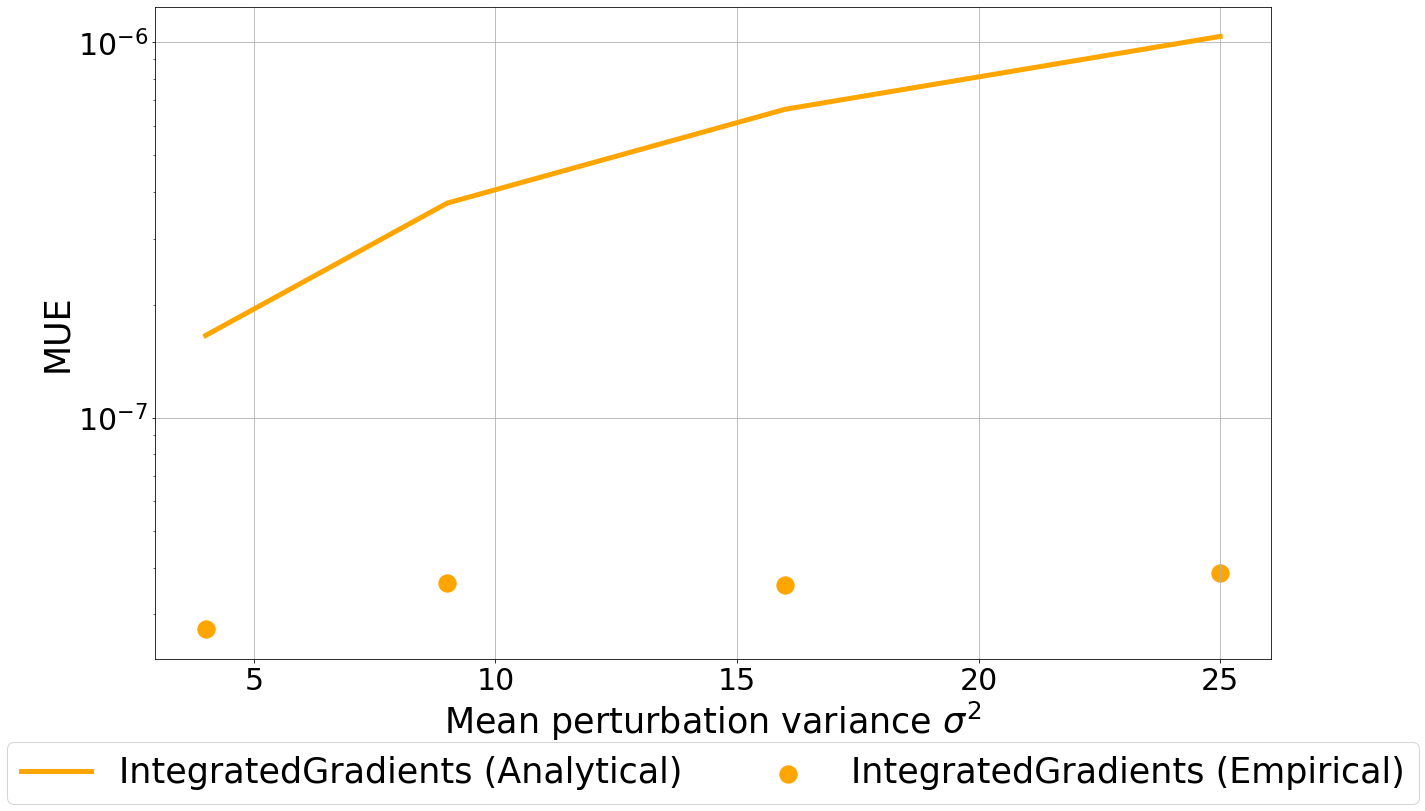

In [12]:
# Plot aggregations for int parameters
colors=['red', 'blue', 'orange', 'green']
stds = np.asarray(stds)
fsize = 35
stds = stds_int
fig = plt.figure(figsize=(20, 12))
for (name, data), col in zip(agg_results.items(), colors):
    if name == 'IntegratedGradients':
        plt.plot(stds*stds, np.asarray(data['analytical'])[:len(stds)]/m, label=f"{name} (Analytical)", c=col, lw=5)
        plt.scatter(stds_int*stds_int, np.asarray(data['empirical'])[:len(stds)]/m,  marker='o', 
                    label=f"{name} (Empirical)", c=col, s=300)
plt.xlabel('Mean perturbation variance $\sigma^2$', fontsize=fsize)
plt.ylabel('MUE', fontsize=fsize)
plt.yscale('log')
plt.xticks(fontsize=fsize-5);plt.yticks(fontsize=fsize-5)
plt.legend(fontsize=fsize, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
plt.grid(True)
plt.show()
#fig.savefig('./figures/uncertainties_input_tabular_agg.png', bbox_inches='tight')